#Clase 2. Regresión Lineal Múltiple: Escenarios


# 1. FASE RECOLECCIÓN DE DATOS

In [2]:
#importamos fichero local
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
#Libreria de Pandas
import pandas as pd

In [4]:
df_insurance = pd.read_csv('insurance.csv')
df_insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df_insurance.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


# 2. FASE EXPLORATORIA

Recuerda: Este apartado lo hemos trabajado en el cuaderno de trabajo sobre análisis exploratorio.

# 3. FASE DE ENTRENAMIENTO Y 4. FASE DE VALIDACIÓN

## HIPOTESIS 1:  Vamos a utilizar en esta hipótesis **sólo variables numéricas.**

In [13]:
# preparamos el dataset para nuestra hipotesis 1. Eliminando las variables categoricas.
cat_cols = ['sex', 'smoker', 'region']
df_insurance_hip1 = df_insurance.drop(cat_cols, axis=1)
df_insurance_hip1.head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


Definimos nuestra variable independiente "X" y nuestra variable dependiente "Y" que es la variable objetivo.

In [14]:
# Definicion de varibles X, Y
x_hip1 = df_insurance_hip1.drop('charges', axis=1)
y_hip1 = df_insurance_hip1['charges']

Preparamos train data y test data para Hipotesis 1.

In [15]:
# preparamos train data y test data
from sklearn.model_selection import train_test_split
x_train_hip1, x_test_hip1, y_train_hip1, y_test_hip1 = train_test_split(x_hip1, y_hip1, test_size=0.2, random_state=42)

Hacemos la regresión lineal, y luego vamos a entrenar nuestro modelo con la funcion **fit**

In [16]:
#Regresion lineal
from sklearn.linear_model import LinearRegression
regresion_lineal = LinearRegression()
regresion_lineal.fit(x_train_hip1, y_train_hip1)

LinearRegression()

In [17]:
print(regresion_lineal.intercept_, regresion_lineal.coef_)

-6118.046178106708 [220.75776541 332.20247584 563.01943242]


 FASE DE VALIDACIÓN.  Hipótesis 1.

En cada hipótesis nos vamos a centrar en la métrica "error cuadrático medio". Existen otras métricas que te invito a probar y discutir.

In [18]:
# metrica de error cuadrático medio (MSE).
from sklearn.metrics import mean_squared_error

Validemos el modelo con la Hipótesis 1.

In [19]:
#validación del modelo. Entrenamiento.
pred_train_hip1 = regresion_lineal.predict(x_train_hip1)
mse_train_hip1 = mean_squared_error(y_train_hip1, pred_train_hip1)


Validamos con datos de Test.

In [20]:
#utilizamos el Test data.
pred_test_hip1 = regresion_lineal.predict(x_test_hip1)
mse_test_hip1 = mean_squared_error(y_test_hip1, pred_test_hip1)

print('MSE train hipótesis 1:', mse_train_hip1)
print('MSE test hipótesis 1:', mse_test_hip1)

MSE train hipótesis 1: 128475007.01537955
MSE test hipótesis 1: 131201335.64669803


Conclusión Hipótesis 1: Los resultados de nuestra primer hipótesis arroja valores muy altos. Vemos que utilizar sólo las variables numéricas no genera resultados buenos para nuestro modelo.

## HIPÓTESIS 2: One Hot Encoding

Debido al alto error de nuestra primera hipótesis hemos decidido incluir en nuestro análisis todas las columnas del dataset. Cualitativas y cuantitativas.

Para ello trataremos primero las variables categoricas para transformarlas y que tomen valores numéricos.  

Esto lo realizamos con la tecnica de One Hot Encoding.

In [21]:
# transformemos la variables categoricas con la tecnica OHE
#
df_insurance_hip2 = pd.get_dummies(data = df_insurance, prefix = 'OHE', prefix_sep='_',
               columns = ['sex', 'smoker', 'region'],
               drop_first =True,
              dtype='int8')
df_insurance_hip2

,age,bmi,children,charges,OHE_male,OHE_yes,OHE_northwest,OHE_southeast,OHE_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,1,0,0
1334,18,31.920,0,2205.98080,0,0,0,0,0
1335,18,36.850,0,1629.83350,0,0,0,1,0
1336,21,25.800,0,2007.94500,0,0,0,0,1


In [22]:
df_insurance_hip2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1338 non-null   int64  
 1   bmi            1338 non-null   float64
 2   children       1338 non-null   int64  
 3   charges        1338 non-null   float64
 4   OHE_male       1338 non-null   int8   
 5   OHE_yes        1338 non-null   int8   
 6   OHE_northwest  1338 non-null   int8   
 7   OHE_southeast  1338 non-null   int8   
 8   OHE_southwest  1338 non-null   int8   
dtypes: float64(2), int64(2), int8(5)
memory usage: 48.5 KB


Observamos que como han quedado nuestros datos con valores numéricos int8 y float64.

Continuamos preparando nuestra hipótesis definiendo la variable independiente y la variable objetivo.

In [23]:
# Definimos varibles x, y para la hipótesis 2
x_hip2 = df_insurance_hip2.drop('charges', axis=1)
y_hip2 = df_insurance_hip2['charges']

Preparamos el dataset de entrenamiento y de test

In [24]:
# preparamos train data y test data para la hipótesis 2
from sklearn.model_selection import train_test_split
x_train_hip2, x_test_hip2, y_train_hip2, y_test_hip2 = train_test_split(x_hip2, y_hip2, test_size=0.2, random_state=42)


Entrenamos nuestro modelo. Hipotesis 2

In [25]:
# Regresion lineal
from sklearn.linear_model import LinearRegression
regresion_lineal = LinearRegression()
regresion_lineal.fit(x_train_hip2, y_train_hip2)

LinearRegression()

FASE DE VALIDACION. Hipótesis 2

In [26]:
# predecimos los valores para los datos de entrenamiento.
pred_train_hip2 = regresion_lineal.predict(x_train_hip2)

# Calculamos la métrica de Error cuadrático medio. Hipótesis 2.
mse_train_hip2 = mean_squared_error(y_train_hip2, pred_train_hip2)

# predecimos los valores para los datos de test.
pred_test_hip2 = regresion_lineal.predict(x_test_hip2)

# Calculamos la métrica de Error cuadrático medio. Hipótesis 2.
mse_test_hip2 = mean_squared_error(y_test_hip2, pred_test_hip2)

print('MSE train hipótesis 1:', mse_train_hip1)
print('MSE test hipótesis 1:', mse_test_hip1)
print()
print('MSE train hipótesis 2:', mse_train_hip2)
print('MSE test hipótesis 2:', mse_test_hip2)

MSE train hipótesis 1: 128475007.01537955
MSE test hipótesis 1: 131201335.64669803

MSE train hipótesis 2: 37277681.70201867
MSE test hipótesis 2: 33596915.85136145


Conclusión Hipótesis 2: Hemos mejorado en la predicción respecto a la hipótesis 1, pero los valores de la métrica aún siguen alejados del valor cero (0).  Así que evaluaremos otras hipótesis.  Para ello vamos a preprocesar los datos normalizando alguna de nuestras variables utilizando los escalers.

## HIPÓTESIS 3. Vamos a normalizar en base al estandar Scaler de la librería de Scikit learn.

Seguimos utilizando el dataset con todas las columnas, por lo tanto, volvemos a utilizar la técnica OHE.

In [27]:
# transformemos la variables categoricas con la tecnica OHE
#
df_insurance_hip3 = pd.get_dummies(data = df_insurance, prefix = 'OHE', prefix_sep='_',
               columns = ['sex', 'smoker', 'region'],
               drop_first =True,
              dtype='int8')
df_insurance_hip3

,age,bmi,children,charges,OHE_male,OHE_yes,OHE_northwest,OHE_southeast,OHE_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,1,0,0
1334,18,31.920,0,2205.98080,0,0,0,0,0
1335,18,36.850,0,1629.83350,0,0,0,1,0
1336,21,25.800,0,2007.94500,0,0,0,0,1


Creamos nuestra variable independiente y variable objetivo.

In [28]:
# Creacion de variables x, y. Hipótesis 3.
x_hip3 = df_insurance_hip3.drop('charges', axis=1)
y_hip3 = df_insurance_hip3['charges']

Escalamos la variable **charges** (objetivo) para hacerla más estandar.
Para poderla preprocesar con nuestra funcion StandardScaler debemos transformar nuestro dataset en una matriz numerica de numpy.

In [29]:
#escalamos la variable charges
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
# Vamos a convertir nuestra variable en un array para procesarla.
y_hip3 = sc.fit_transform(y_hip3.to_numpy().reshape(-1,1))
# Volvemos a transformar nuestro dataser en un array de 1xn.
y_hip3 = y_hip3.reshape(1,-1)[0]

Preparemos el train data y test data.

In [30]:
# preramos los datos y separamos 80% train y 20% para test.
from sklearn.model_selection import train_test_split
x_train_hip3, x_test_hip3, y_train_hip3, y_test_hip3 = train_test_split(x_hip3, y_hip3, test_size=0.2, random_state=42)

#preparamos train data y test data. Hipótesis 3.
from sklearn.linear_model import LinearRegression
regresion_lineal = LinearRegression()
#entrenamos
regresion_lineal.fit(x_train_hip3, y_train_hip3)


LinearRegression()

FASE VALIDACIÓN. Hipótesis 3.

In [31]:
#predecimos valores
pred_train_hip3 = regresion_lineal.predict(x_train_hip3)

#calculamos la metrica de error cuadratico medio.
mse_train_hip3 = mean_squared_error(y_train_hip3, pred_train_hip3)

# predecimos los valores con datos de test
pred_test_hip3 = regresion_lineal.predict(x_test_hip3)

#calculamos la metrica de error cuadratico medio.
mse_test_hip3 = mean_squared_error(y_test_hip3, pred_test_hip3)


print('MSE train hipótesis 2:', mse_train_hip2)
print('MSE test hipótesis 2:', mse_test_hip2)
print()
print('MSE train hipótesis 3:', mse_train_hip3)
print('MSE test hipótesis 3:', mse_test_hip3)



MSE train hipótesis 2: 37277681.70201867
MSE test hipótesis 2: 33596915.85136145

MSE train hipótesis 3: 0.2543809059566236
MSE test hipótesis 3: 0.22926355667538653


Conclusión Hipótesis 3: Ahora nos encontramos con valores mucho mejores que las hipótesis anteriores. Hemos mostrado los valores de la hipótesis 2 y 3 para hacer el comparativo.  Hasta este punto nuestro modelo ha alcanzado un nivel aceptable de entrenamiento.

Sin embargo podemos seguir normalinzando con otro escaler para comparar los resultados.

# 4. FASE DE PREDICCIÓN

Para la predicción "final" de nuestro modelo utilizamos la estrategia de nuestra hipótesis 3.

In [32]:
# Predicción final en base a regresión lineal
# predecimos los valores con datos de test para hipótesis 3
y_test = y_test_hip3
y_pred = regresion_lineal.predict(x_test_hip3)

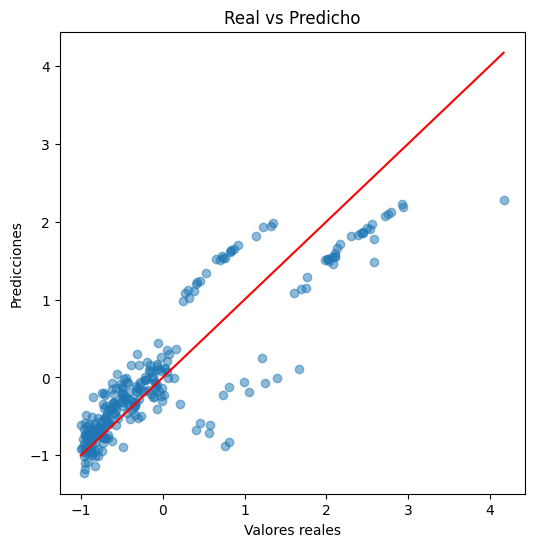

In [33]:
# representamos gráficamente la relación entre real (test) y predicción
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")

# línea perfecta
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()